## 1. Import Necessary Libraries

In [12]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.8 MB/s  0:00:00


In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report,precision_score
import warnings
warnings.filterwarnings("ignore")

## 2. Import Dataset

In [5]:
credit_card_data=pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding

**Exploring the variable**

* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Maritaltatus (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for 1 month
2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

*  BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

*  BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

### **Target variable**

default.payment.next.month: Default payment (1=yes, 0=no)

#### Note: NT is Taiwain Dollars

## 3. Data Understanding

In [6]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [9]:
credit_card_data.shape

(30000, 25)

In [8]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4. Data Preparation

In [10]:
del credit_card_data["ID"]

In [23]:
le=LabelEncoder()
credit_card_data["SEX"]=le.fit_transform(credit_card_data["SEX"])
credit_card_data["EDUCATION"]=le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"]=le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [24]:
credit_card_data.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5. Model Building

In [33]:
X = credit_card_data.drop("DEFAULT",axis=1)
y = credit_card_data["DEFAULT"]

In [36]:
X.shape,y.shape

((30000, 23), (30000,))

In [37]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=None)

In [38]:
X_train.shape,y_train.shape

((24000, 23), (24000,))

In [39]:
X_test.shape,y_test.shape

((6000, 23), (6000,))

## 6. Model Training

In [44]:
adb_classifier=AdaBoostClassifier()
gb_classifier=GradientBoostingClassifier(n_estimators=50)
xgb_classifier=XGBClassifier(n_estimators=50)
lgbm_classifier=LGBMClassifier(n_estimators=50)

In [47]:
%%time
adb_classifier.fit(X_train,y_train)

CPU times: total: 3.83 s
Wall time: 3.84 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [48]:
%%time
gb_classifier.fit(X_train,y_train)

CPU times: total: 8.95 s
Wall time: 9.52 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [52]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: total: 2.23 s
Wall time: 320 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [54]:
%%time
lgbm_classifier.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5332, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222167 -> initscore=-1.253084
[LightGBM] [Info] Start training from score -1.253084
CPU times: total: 984 ms
Wall time: 233 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,50
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Model Testing 

In [56]:
y_pred_adb=adb_classifier.predict(X_test)
y_pred_gb=gb_classifier.predict(X_test)
y_pred_xgb=xgb_classifier.predict(X_test)
y_pred_lgb=lgbm_classifier.predict(X_test)

## 8. Model Evalution

#### ADA BOOSTING EVALUTION

In [62]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_pred_adb),4))
print("Precision Score  : ",round(precision_score(y_test,y_pred_adb),4))
print("Recall Score     : ",round(recall_score(y_test,y_pred_adb),4))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred_adb))

Accuracy Score   :  0.8215
Precision Score  :  0.679
Recall Score     :  0.339
Confusion Matrix : 
 [[4487  209]
 [ 862  442]]


#### GRADIENT BOOSTING EVALUTION

In [63]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_pred_gb),4))
print("Precision Score  : ",round(precision_score(y_test,y_pred_gb),4))
print("Recall Score     : ",round(recall_score(y_test,y_pred_gb),4))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred_gb))

Accuracy Score   :  0.823
Precision Score  :  0.6613
Recall Score     :  0.3804
Confusion Matrix : 
 [[4442  254]
 [ 808  496]]


#### EXTREME GRADIENT BOOSTING EVALUTION

In [64]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score  : ",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score     : ",round(recall_score(y_test,y_pred_xgb),4))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score   :  0.8152
Precision Score  :  0.6188
Recall Score     :  0.3896
Confusion Matrix : 
 [[4383  313]
 [ 796  508]]


#### LIGHT GRADIENT BOOSTING EVALUTION

In [65]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_pred_lgb),4))
print("Precision Score  : ",round(precision_score(y_test,y_pred_lgb),4))
print("Recall Score     : ",round(recall_score(y_test,y_pred_lgb),4))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred_lgb))

Accuracy Score   :  0.8233
Precision Score  :  0.658
Recall Score     :  0.3896
Confusion Matrix : 
 [[4432  264]
 [ 796  508]]


# FEATURE IMPORTANCE

In [71]:
adb_feature_importances=adb_classifier.feature_importances_
gb_feature_importances=gb_classifier.feature_importances_
xgb_feature_importances=xgb_classifier.feature_importances_
lgbm_feature_importances=lgbm_classifier.feature_importances_

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [76]:
feature_importance_list=pd.DataFrame(data={"Features":x.columns,
                                           "Adaboost_features":adb_feature_importances,
                                           "GB__features":gb_feature_importances,
                                           "XGB__features":xgb_feature_importances,
                                           "LGB__features":lgbm_feature_importances})
feature_importance_list

,Features,Adaboost_features,GB__features,XGB__features,LGB__features
0,LIMIT_BAL,0.042060,0.019116,0.019588,125
1,SEX,0.015073,0.001890,0.012274,18
2,EDUCATION,0.000000,0.000956,0.015643,25
3,MARRIAGE,0.017987,0.002257,0.017665,18
4,AGE,0.000000,0.005443,0.014088,93
5,PAY_1,0.491349,0.661555,0.430064,60
6,PAY_2,0.019865,0.085709,0.116907,29
7,PAY_3,0.050885,0.038421,0.050592,35
8,PAY_4,0.007140,0.016470,0.036560,30
9,PAY_5,0.022668,0.021282,0.043445,29


### Question 1 - Display the Top 10 Features of Ada-Boost

In [77]:
import seaborn as sns

<Axes: xlabel='Adaboost_features', ylabel='Features'>

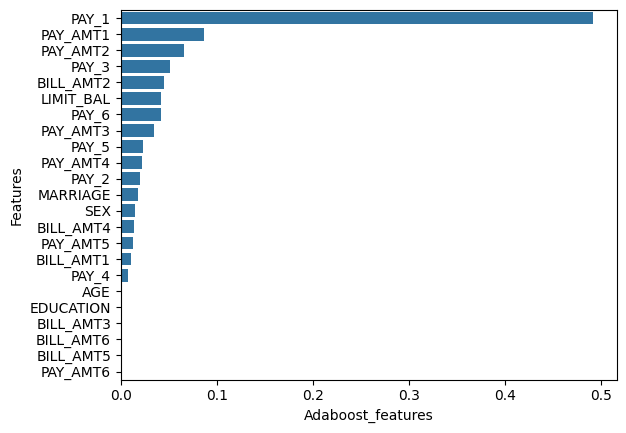

In [86]:
adaboost_top_features=feature_importance_list.sort_values( by="Adaboost_features",ascending = False)
sns.barplot(data=adaboost_top_features, y="Features", x="Adaboost_features")

In [87]:
adaboost_top_features.head(10)

,Features,Adaboost_features,GB__features,XGB__features,LGB__features
5,PAY_1,0.491349,0.661555,0.430064,60
17,PAY_AMT1,0.086991,0.019395,0.018134,72
18,PAY_AMT2,0.066076,0.025522,0.023589,117
7,PAY_3,0.050885,0.038421,0.050592,35
12,BILL_AMT2,0.044567,0.005035,0.017131,73
0,LIMIT_BAL,0.042060,0.019116,0.019588,125
10,PAY_6,0.041641,0.024429,0.038561,49
19,PAY_AMT3,0.035044,0.017636,0.016594,85
9,PAY_5,0.022668,0.021282,0.043445,29
20,PAY_AMT4,0.021579,0.010399,0.016517,87


### Question 2 - Display the Top 10 Features of Gradient-Boost

<Axes: xlabel='GB__features', ylabel='Features'>

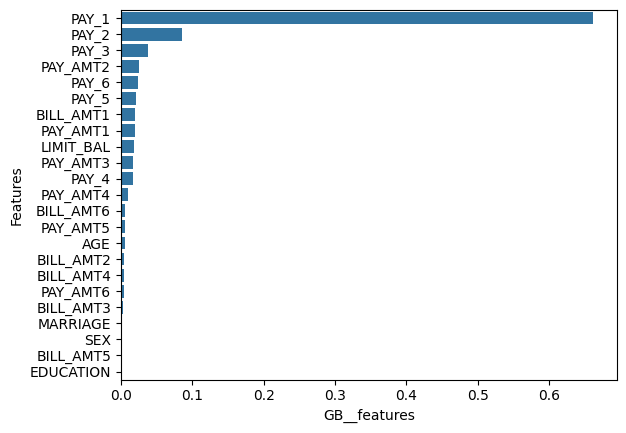

In [89]:
GB_top_features=feature_importance_list.sort_values( by="GB__features",ascending = False)
sns.barplot(data=GB_top_features, y="Features", x="GB__features")

In [91]:
GB_top_features.head(10)

,Features,Adaboost_features,GB__features,XGB__features,LGB__features
5,PAY_1,0.491349,0.661555,0.430064,60
6,PAY_2,0.019865,0.085709,0.116907,29
7,PAY_3,0.050885,0.038421,0.050592,35
18,PAY_AMT2,0.066076,0.025522,0.023589,117
10,PAY_6,0.041641,0.024429,0.038561,49
9,PAY_5,0.022668,0.021282,0.043445,29
11,BILL_AMT1,0.010704,0.020489,0.020391,141
17,PAY_AMT1,0.086991,0.019395,0.018134,72
0,LIMIT_BAL,0.042060,0.019116,0.019588,125
19,PAY_AMT3,0.035044,0.017636,0.016594,85


### Question 3 - Display the Top 10 Features of Extreme-Gradient-Boost

<Axes: xlabel='XGB__features', ylabel='Features'>

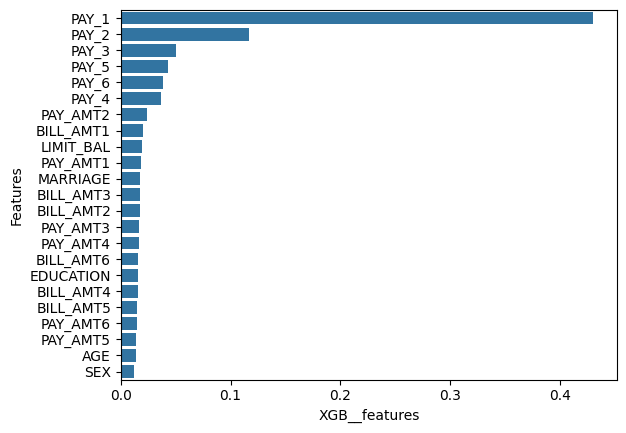

In [92]:
XGB_top_features=feature_importance_list.sort_values( by="XGB__features",ascending = False)
sns.barplot(data=XGB_top_features, y="Features", x="XGB__features")

In [93]:
XGB_top_features.head(10)

,Features,Adaboost_features,GB__features,XGB__features,LGB__features
5,PAY_1,0.491349,0.661555,0.430064,60
6,PAY_2,0.019865,0.085709,0.116907,29
7,PAY_3,0.050885,0.038421,0.050592,35
9,PAY_5,0.022668,0.021282,0.043445,29
10,PAY_6,0.041641,0.024429,0.038561,49
8,PAY_4,0.007140,0.016470,0.036560,30
18,PAY_AMT2,0.066076,0.025522,0.023589,117
11,BILL_AMT1,0.010704,0.020489,0.020391,141
0,LIMIT_BAL,0.042060,0.019116,0.019588,125
17,PAY_AMT1,0.086991,0.019395,0.018134,72


### Question 4 - Display the Top 10 Features of Light-Gradient-Boost

<Axes: xlabel='LGB__features', ylabel='Features'>

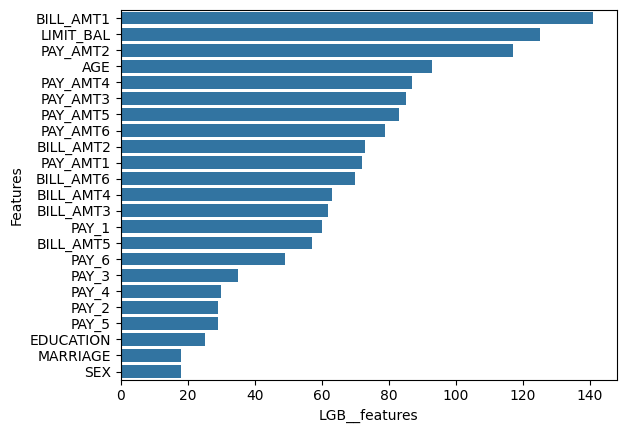

In [94]:
LGB_top_features=feature_importance_list.sort_values( by="LGB__features",ascending = False)
sns.barplot(data=LGB_top_features, y="Features", x="LGB__features")

In [95]:
LGB_top_features.head(10)

,Features,Adaboost_features,GB__features,XGB__features,LGB__features
11,BILL_AMT1,0.010704,0.020489,0.020391,141
0,LIMIT_BAL,0.042060,0.019116,0.019588,125
18,PAY_AMT2,0.066076,0.025522,0.023589,117
4,AGE,0.000000,0.005443,0.014088,93
20,PAY_AMT4,0.021579,0.010399,0.016517,87
19,PAY_AMT3,0.035044,0.017636,0.016594,85
21,PAY_AMT5,0.012670,0.005719,0.014241,83
22,PAY_AMT6,0.000000,0.004251,0.014443,79
12,BILL_AMT2,0.044567,0.005035,0.017131,73
17,PAY_AMT1,0.086991,0.019395,0.018134,72


## THE END